In [3]:
import pandas as pd

df = pd.read_csv("Advertising.csv")

print(df.shape)
df.head()

(200, 5)


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [4]:
print("First 10 Rows")
display(df.head(10))

print("\nLast 10 Rows")
display(df.tail(10))

print("\nShape")
print(df.shape)

print("\nColumns")
print(df.columns)

print("\nData Types")
print(df.dtypes)

print("\nInfo")
df.info()

First 10 Rows


,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9
5,6,8.7,48.9,75.0,7.2
6,7,57.5,32.8,23.5,11.8
7,8,120.2,19.6,11.6,13.2
8,9,8.6,2.1,1.0,4.8
9,10,199.8,2.6,21.2,10.6



Last 10 Rows


,Unnamed: 0,TV,radio,newspaper,sales
190,191,39.5,41.1,5.8,10.8
191,192,75.5,10.8,6.0,9.9
192,193,17.2,4.1,31.6,5.9
193,194,166.8,42.0,3.6,19.6
194,195,149.7,35.6,6.0,17.3
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4



Shape
(200, 5)

Columns
Index(['Unnamed: 0', 'TV', 'radio', 'newspaper', 'sales'], dtype='object')

Data Types
Unnamed: 0      int64
TV            float64
radio         float64
newspaper     float64
sales         float64
dtype: object

Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   radio       200 non-null    float64
 3   newspaper   200 non-null    float64
 4   sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [5]:
print("Missing Values")
print(df.isnull().sum())

print("\nMissing Percentage")
print((df.isnull().sum()/len(df))*100)

print("\nDuplicate Rows")
print(df.duplicated().sum())

Missing Values
Unnamed: 0    0
TV            0
radio         0
newspaper     0
sales         0
dtype: int64

Missing Percentage
Unnamed: 0    0.0
TV            0.0
radio         0.0
newspaper     0.0
sales         0.0
dtype: float64

Duplicate Rows
0


In [6]:
# Remove duplicates
df = df.drop_duplicates()

# Rename columns
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print(df.head())

   unnamed:_0     tv  radio  newspaper  sales
0           1  230.1   37.8       69.2   22.1
1           2   44.5   39.3       45.1   10.4
2           3   17.2   45.9       69.3    9.3
3           4  151.5   41.3       58.5   18.5
4           5  180.8   10.8       58.4   12.9


In [7]:
df["sales_category"] = pd.cut(
    df["sales"],
    bins=[0,10,20,30],
    labels=["Low","Medium","High"]
)

df["tv_level"] = pd.cut(
    df["tv"],
    bins=3,
    labels=["Low","Medium","High"]
)

df["radio_tv_ratio"] = df["radio"] / (df["tv"] + 1)

df.head()

,unnamed:_0,tv,radio,newspaper,sales,sales_category,tv_level,radio_tv_ratio
0,1,230.1,37.8,69.2,22.1,High,High,0.163566
1,2,44.5,39.3,45.1,10.4,Medium,Low,0.863736
2,3,17.2,45.9,69.3,9.3,Low,Low,2.521978
3,4,151.5,41.3,58.5,18.5,Medium,Medium,0.270820
4,5,180.8,10.8,58.4,12.9,Medium,Medium,0.059406


In [8]:
df.describe()

,unnamed:_0,tv,radio,newspaper,sales,radio_tv_ratio
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500,0.492774
std,57.879185,85.854236,14.846809,21.778621,5.217457,1.785535
min,1.000000,0.700000,0.000000,0.300000,1.600000,0.000000
25%,50.750000,74.375000,9.975000,12.750000,10.375000,0.072593
50%,100.500000,149.750000,22.900000,25.750000,12.900000,0.146543
75%,150.250000,218.825000,36.525000,45.100000,17.400000,0.272817
max,200.000000,296.400000,49.600000,114.000000,27.000000,23.294118


In [10]:
category_summary = (
    df.groupby("sales_category")
    .agg(
        average_sales=("sales","mean"),
        average_tv=("tv","mean"),
        average_radio=("radio","mean")
    )
)

category_summary

C:\Users\ABHIRAM KODALI\AppData\Local\Temp\ipykernel_15536\682027997.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("sales_category")


,average_sales,average_tv,average_radio
sales_category,,,
Low,7.766667,38.233333,17.328889
Medium,14.089516,162.385484,21.153226
High,22.835484,243.619355,40.322581


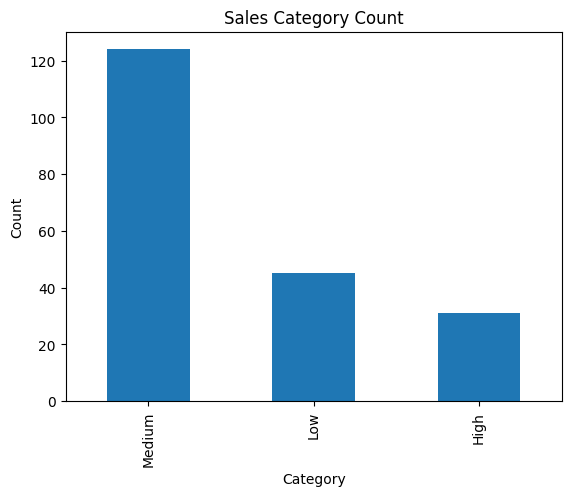

In [11]:
import matplotlib.pyplot as plt

df["sales_category"].value_counts().plot(
    kind="bar"
)

plt.title("Sales Category Count")
plt.xlabel("Category")
plt.ylabel("Count")

plt.show()

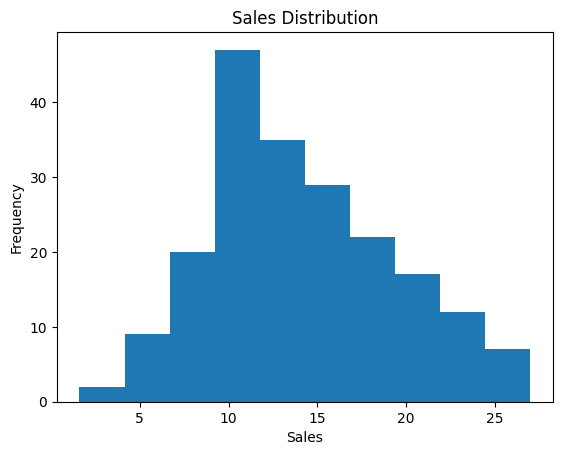

In [12]:
plt.hist(df["sales"], bins=10)

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

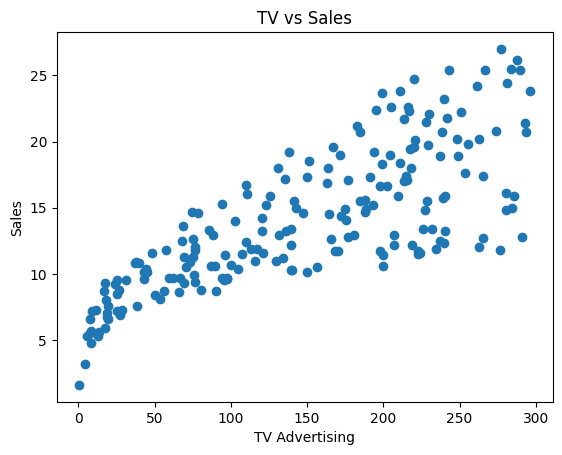

In [13]:
plt.scatter(df["tv"], df["sales"])

plt.title("TV vs Sales")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")

plt.show()

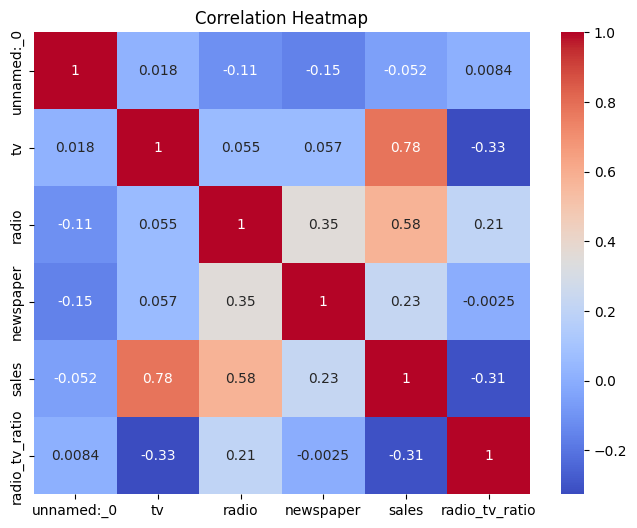

In [14]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()